# 04 - Decision Tree

Arvore de decisao em Spark MLlib, respeitando a restricao do enunciado de nao usar ensembles.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, VectorIndexer
from pyspark.ml.regression import DecisionTreeRegressor

from _lib import (
    build_spark, append_metric,
    SEED, SPLIT_DATE, CLEAN_DATA_PATH, TARGET_COL,
    NUMERIC_COLS, CATEGORICAL_COLS,
)

MODEL_OUTPUT = '/models/decision_tree'
IMPORTANCE_PLOT = '/results/feature_importance_decision_tree.png'
RESIDUAL_PLOT  = '/results/residual_analysis_dt.png'

spark = build_spark('nyc-rideshare-decision-tree')
sns.set_theme(style='whitegrid')

In [2]:
silver_df = spark.read.parquet(CLEAN_DATA_PATH)
silver_df.createOrReplaceTempView('trips_clean')

# Split temporal via Spark SQL puro (regra do projeto: data prep em SQL, ML pipeline em Python).
train_df = spark.sql(f"""
    SELECT * FROM trips_clean
    WHERE date < '{SPLIT_DATE}'
""").cache()
test_df = spark.sql(f"""
    SELECT * FROM trips_clean
    WHERE date >= '{SPLIT_DATE}'
""").cache()

train_rows = train_df.count()
test_rows = test_df.count()
if train_rows == 0 or test_rows == 0:
    raise ValueError('O split temporal exige dados antes e depois de 2023-06-01. Um unico mes como 2023-08 nao basta para treinar e avaliar.')

train_rows, test_rows

(56282410, 53834403)

## 1. Pipeline de features e split temporal

Mesmo split temporal de 03 (`date < 2023-06-01` para treino, ≥ para teste), em SQL puro. O pipeline usa `StringIndexer` + `VectorIndexer` (em vez de OneHot do LR) porque árvores lidam nativamente com categóricas indexadas — sem precisar expandir a dimensionalidade. `maxCategories=8` e `handleInvalid='keep'` são necessários porque `month_of_year` tem valores diferentes em treino (3,4,5) e teste (6,7,8) por força do split temporal — sem `keep` o `transform` falharia.

In [3]:
indexers = [
    StringIndexer(inputCol=col_name, outputCol=f'{col_name}_idx', handleInvalid='keep')
    for col_name in CATEGORICAL_COLS
]
feature_cols = NUMERIC_COLS + [f'{col_name}_idx' for col_name in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features_raw')
# VectorIndexer marca features com <= maxCategories valores unicos como categoricas.
# handleInvalid='keep' e necessario: month_of_year tem 3 valores no treino (3,4,5) mas
# 3 valores diferentes no teste (6,7,8) — sem keep o transform falha com invalid value.
vector_indexer = VectorIndexer(inputCol='features_raw', outputCol='features', maxCategories=8, handleInvalid='keep')
dt = DecisionTreeRegressor(
    labelCol=TARGET_COL,
    featuresCol='features',
    predictionCol='prediction',
    maxDepth=8,
    maxBins=256,
    seed=SEED
)

pipeline = Pipeline(stages=indexers + [assembler, vector_indexer, dt])

## 2. Treino e avaliação global

`DecisionTreeRegressor` com `maxDepth=8` e `maxBins=256`. O enunciado pede árvore de decisão e não ensemble — não trocar por `GBTRegressor` ou `RandomForestRegressor` mesmo com ganho de performance. Tempo de treino é ~2× o do LR pelo custo dos splits em features categóricas de alta cardinalidade (264 zonas).

In [4]:
start_time = time.perf_counter()
dt_model = pipeline.fit(train_df)
train_seconds = time.perf_counter() - start_time

dt_model.write().overwrite().save(MODEL_OUTPUT)
print(f'Modelo salvo em {MODEL_OUTPUT} | treino: {train_seconds:.2f}s')

Modelo salvo em /models/decision_tree | treino: 436.40s


In [5]:
predictions = dt_model.transform(test_df).cache()
evaluators = {
    'rmse': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='rmse'),
    'mae': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='mae'),
    'r2': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='r2')
}
metrics = {name: evaluator.evaluate(predictions) for name, evaluator in evaluators.items()}
metrics

{'rmse': 8.90886568780014, 'mae': 5.1336941995231395, 'r2': 0.8126139003711689}

### 2.1 R² observado × expectativa

R² = 0,813, ligeiramente superior ao LR (0,806) mas bem abaixo dos ~0,90 do CLAUDE.md. Mesma causa do 03: schema reduzido limita o teto. O ganho marginal sobre o LR vem da capacidade da árvore de capturar não-linearidades em buckets (e.g., desconto por bairro de baixa demanda), enquanto o LR fica preso à estrutura linear. Erros estratificados (próxima seção) mostram que o ganho concentra-se em corridas curtas (0-2 mi) e fora de Manhattan.

In [6]:
predictions.createOrReplaceTempView('predictions_dt')

spark.sql("""
SELECT
    pu_borough,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1
ORDER BY rmse DESC
""").show(truncate=False)

spark.sql("""
SELECT
    CASE
        WHEN trip_length < 2 THEN '0-2 mi'
        WHEN trip_length < 5 THEN '2-5 mi'
        WHEN trip_length < 10 THEN '5-10 mi'
        ELSE '10+ mi'
    END AS distance_bucket,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1
ORDER BY distance_bucket
""").show(truncate=False)

+-------------+-------+-------+--------+
|pu_borough   |rmse   |mae    |rows    |
+-------------+-------+-------+--------+
|EWR          |80.3461|65.4017|3       |
|Manhattan    |10.5479|6.5852 |21135073|
|Queens       |9.1474 |4.9739 |11096402|
|Brooklyn     |7.2039 |4.0328 |14457628|
|Staten Island|6.7391 |3.4895 |782289  |
|Bronx        |5.7028 |3.2945 |6363008 |
+-------------+-------+-------+--------+



+---------------+-------+-------+--------+
|distance_bucket|rmse   |mae    |rows    |
+---------------+-------+-------+--------+
|0-2 mi         |4.7704 |2.8074 |18523719|
|10+ mi         |17.1648|11.5506|6054673 |
|2-5 mi         |6.7899 |4.304  |19015145|
|5-10 mi        |10.7826|7.0882 |10240866|
+---------------+-------+-------+--------+



## 3. Erro estratificado por borough e distância

RMSE/MAE quebrados por `pu_borough` e por bucket de distância. Padrão similar ao LR (Manhattan caro, Bronx barato; erro cresce com a distância), mas com nível absoluto sistematicamente menor — o ganho da árvore é homogêneo entre estratos. Observação: linha EWR aparece com volume residual (3 corridas) — leitura comparativa fica nos boroughs principais.

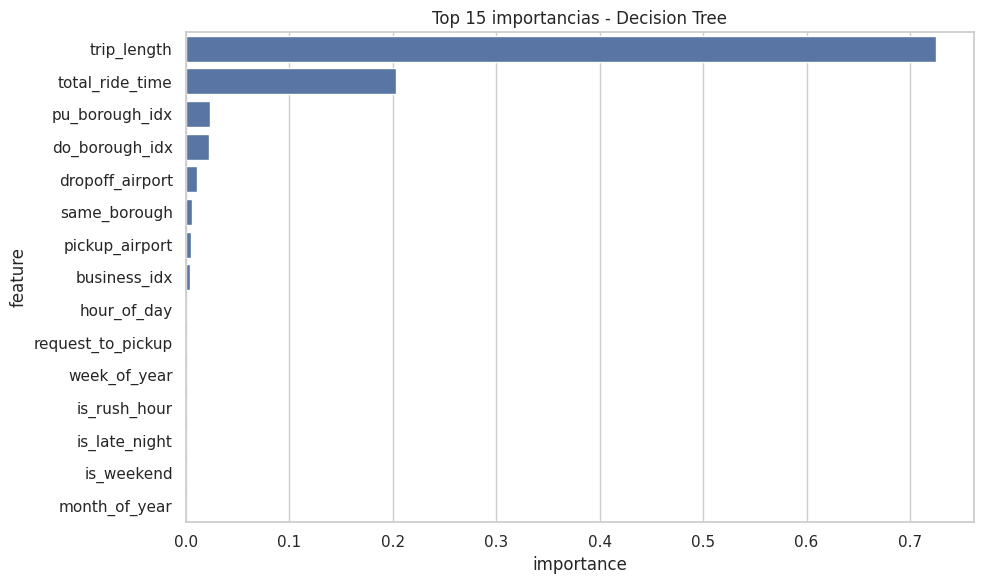

,feature,importance
0,trip_length,0.725679
1,total_ride_time,0.203399
15,pu_borough_idx,0.023605
16,do_borough_idx,0.021915
12,dropoff_airport,0.010676
13,same_borough,0.005786
11,pickup_airport,0.004654
14,business_idx,0.003943
4,hour_of_day,0.000129
2,request_to_pickup,0.000118


In [7]:
tree_stage = dt_model.stages[-1]
importance_pdf = pd.DataFrame({
    'feature': feature_cols,
    'importance': list(tree_stage.featureImportances)
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_pdf.head(15), x='importance', y='feature')
plt.title('Top 15 importancias - Decision Tree')
plt.tight_layout()
plt.savefig(IMPORTANCE_PLOT, dpi=150, bbox_inches='tight')
plt.show()

importance_pdf.head(15)

## 4. Análise visual: importâncias, resíduos e estratificações por gráfico

Top-15 feature importances (do `.featureImportances` do `DecisionTreeRegressor`), histograma de resíduos, scatter resíduo × predito, hexbin predito × real, RMSE/MAE por borough e por bucket de distância, e resíduo médio por hora estratificado por operadora (Uber × Lyft). O gráfico de operadora ajuda a checar se o modelo trata as duas de forma consistente.

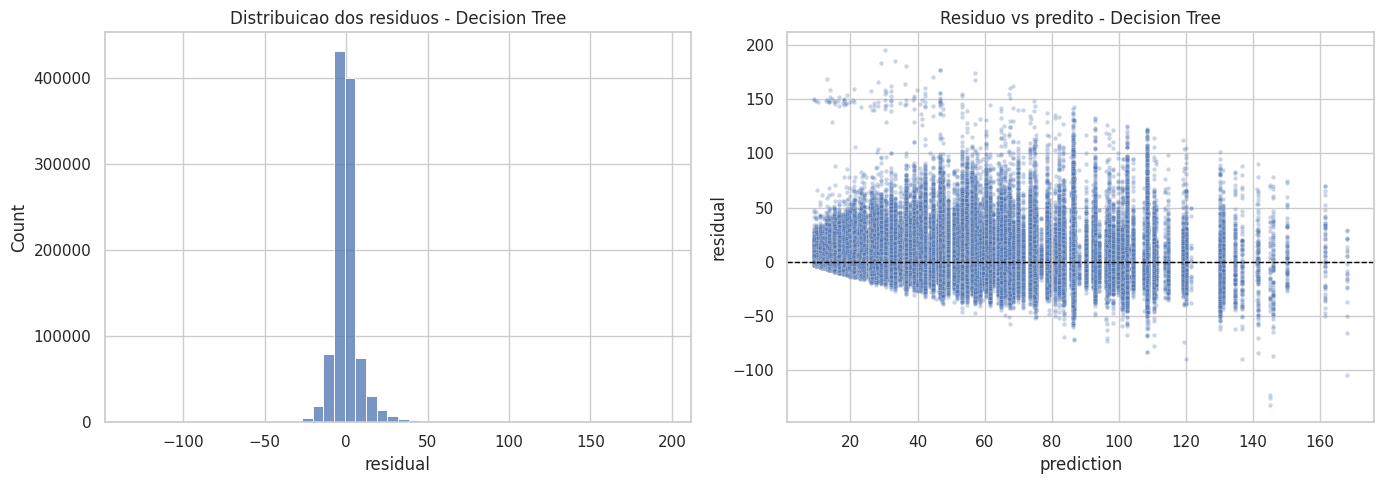

In [8]:
residual_pdf = (
    predictions
    .select('prediction', TARGET_COL)
    .sample(False, 0.02, SEED)
    .toPandas())
residual_pdf['residual'] = residual_pdf[TARGET_COL] - residual_pdf['prediction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residual_pdf['residual'], bins=50, ax=axes[0])
axes[0].set_title('Distribuicao dos residuos - Decision Tree')
sns.scatterplot(data=residual_pdf, x='prediction', y='residual', s=10, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuo vs predito - Decision Tree')
plt.tight_layout()
plt.savefig(RESIDUAL_PLOT, dpi=150, bbox_inches='tight')
plt.show()

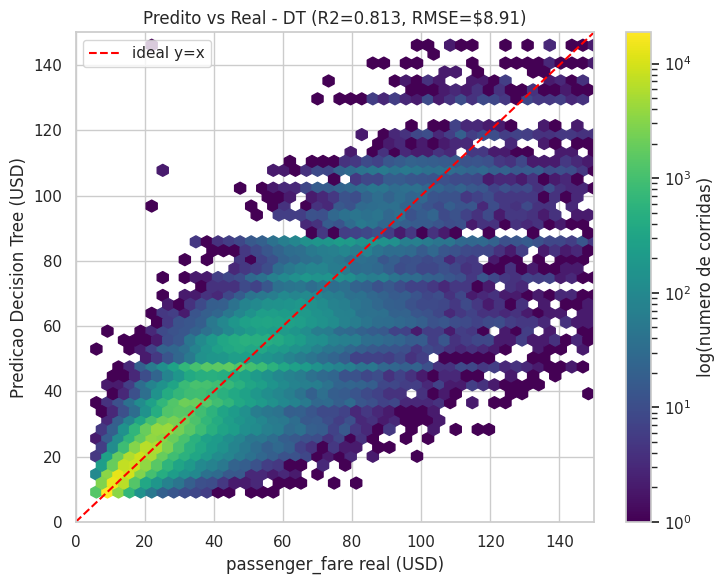

In [9]:

# Predito vs real (hexbin)
import numpy as np
pa_pdf = (predictions
    .select('prediction', TARGET_COL)
    .sample(False, 0.005, SEED)
    .toPandas())
pa_pdf = pa_pdf[(pa_pdf[TARGET_COL].between(0, 150)) & (pa_pdf['prediction'].between(0, 150))]

fig, ax = plt.subplots(figsize=(7.5, 6))
hb = ax.hexbin(pa_pdf[TARGET_COL], pa_pdf['prediction'], gridsize=45, bins='log',
               cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=ax, label='log(numero de corridas)')
lim = [0, 150]
ax.plot(lim, lim, color='red', linestyle='--', linewidth=1.5, label='ideal y=x')
ax.set_xlabel('passenger_fare real (USD)')
ax.set_ylabel('Predicao Decision Tree (USD)')
ax.set_title(f'Predito vs Real - DT (R2={metrics["r2"]:.3f}, RMSE=${metrics["rmse"]:.2f})')
ax.legend()
ax.set_xlim(lim); ax.set_ylim(lim)
fig.tight_layout()
plt.show()


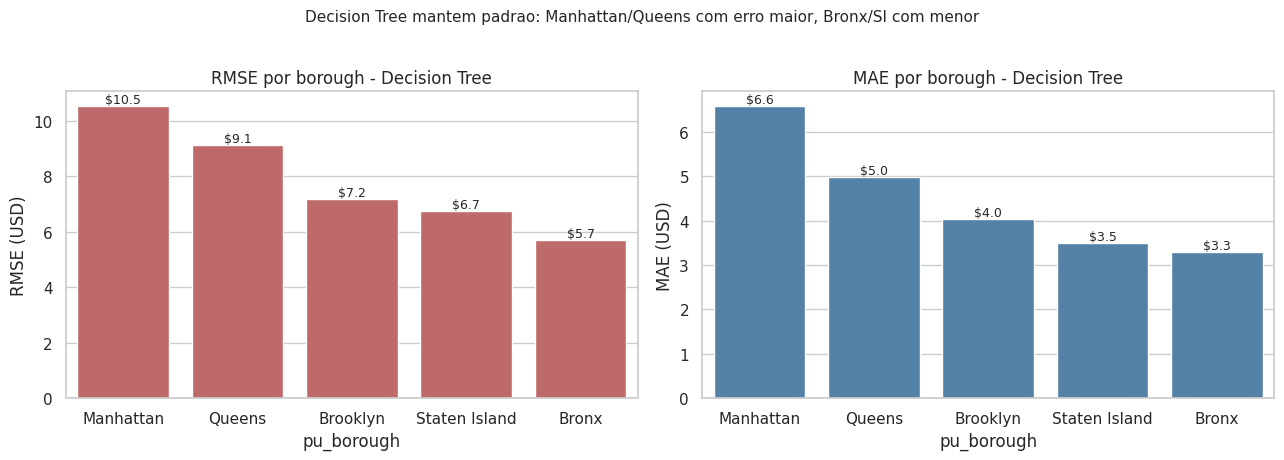

In [10]:

# RMSE/MAE por borough
borough_metric_pdf = spark.sql("""
SELECT
    pu_borough,
    SQRT(AVG(POWER(passenger_fare - prediction, 2))) AS rmse,
    AVG(ABS(passenger_fare - prediction)) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1
HAVING COUNT(*) > 1000
ORDER BY rmse DESC
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=borough_metric_pdf, x='pu_borough', y='rmse', ax=axes[0], color='indianred')
axes[0].set_title('RMSE por borough - Decision Tree')
axes[0].set_ylabel('RMSE (USD)')
for i, row in borough_metric_pdf.iterrows():
    axes[0].text(i, row['rmse'], f"${row['rmse']:.1f}", ha='center', va='bottom', fontsize=9)

sns.barplot(data=borough_metric_pdf, x='pu_borough', y='mae', ax=axes[1], color='steelblue')
axes[1].set_title('MAE por borough - Decision Tree')
axes[1].set_ylabel('MAE (USD)')
for i, row in borough_metric_pdf.iterrows():
    axes[1].text(i, row['mae'], f"${row['mae']:.1f}", ha='center', va='bottom', fontsize=9)

fig.suptitle('Decision Tree mantem padrao: Manhattan/Queens com erro maior, Bronx/SI com menor',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


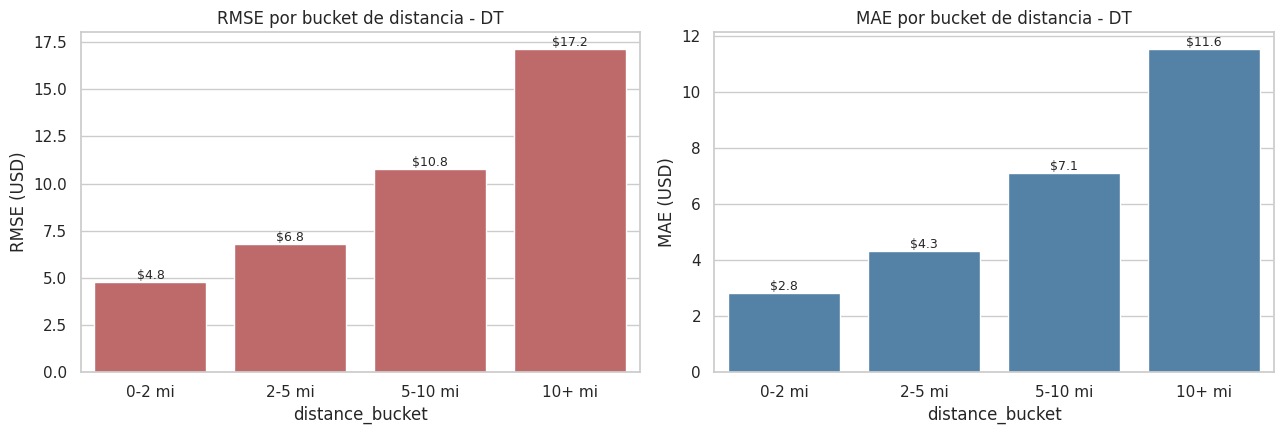

In [11]:

# RMSE/MAE por bucket de distancia
dist_metric_pdf = spark.sql("""
SELECT
    CASE
        WHEN trip_length < 2 THEN '0-2 mi'
        WHEN trip_length < 5 THEN '2-5 mi'
        WHEN trip_length < 10 THEN '5-10 mi'
        ELSE '10+ mi'
    END AS distance_bucket,
    SQRT(AVG(POWER(passenger_fare - prediction, 2))) AS rmse,
    AVG(ABS(passenger_fare - prediction)) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1
""").toPandas()
order = ['0-2 mi', '2-5 mi', '5-10 mi', '10+ mi']
dist_metric_pdf = dist_metric_pdf.set_index('distance_bucket').loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=dist_metric_pdf, x='distance_bucket', y='rmse', ax=axes[0], color='indianred')
axes[0].set_title('RMSE por bucket de distancia - DT')
axes[0].set_ylabel('RMSE (USD)')
for i, row in dist_metric_pdf.iterrows():
    axes[0].text(i, row['rmse'], f"${row['rmse']:.1f}", ha='center', va='bottom', fontsize=9)

sns.barplot(data=dist_metric_pdf, x='distance_bucket', y='mae', ax=axes[1], color='steelblue')
axes[1].set_title('MAE por bucket de distancia - DT')
axes[1].set_ylabel('MAE (USD)')
for i, row in dist_metric_pdf.iterrows():
    axes[1].text(i, row['mae'], f"${row['mae']:.1f}", ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()


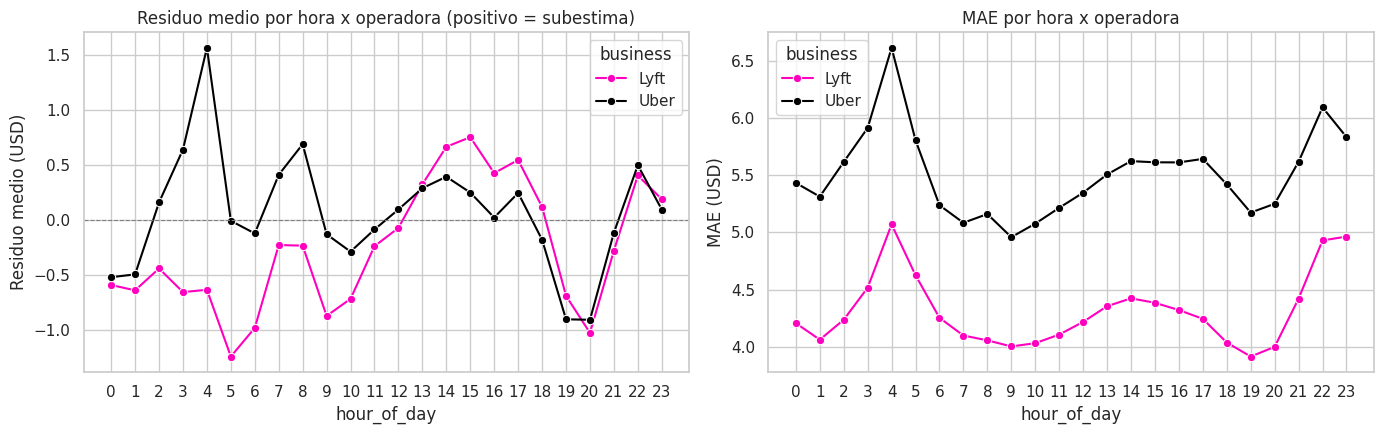

In [12]:

# Residuo medio por hora do dia + por operadora
hour_resid_pdf = spark.sql("""
SELECT
    hour_of_day,
    business,
    AVG(passenger_fare - prediction) AS mean_residual,
    AVG(ABS(passenger_fare - prediction)) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1, 2
ORDER BY 1, 2
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=hour_resid_pdf, x='hour_of_day', y='mean_residual', hue='business',
             ax=axes[0], marker='o', palette={'Uber': '#000000', 'Lyft': '#FF00BF'})
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xticks(range(24))
axes[0].set_title('Residuo medio por hora x operadora (positivo = subestima)')
axes[0].set_ylabel('Residuo medio (USD)')

sns.lineplot(data=hour_resid_pdf, x='hour_of_day', y='mae', hue='business',
             ax=axes[1], marker='o', palette={'Uber': '#000000', 'Lyft': '#FF00BF'})
axes[1].set_xticks(range(24))
axes[1].set_title('MAE por hora x operadora')
axes[1].set_ylabel('MAE (USD)')

fig.tight_layout()
plt.show()


## 5. Persistência das métricas

Append em `results/model_comparison.csv` com run_id, RMSE/MAE/R²/tempo, junto com a configuração `maxDepth=8 maxBins=256`.

In [13]:
results_df = append_metric(
    model='decision_tree',
    rmse=metrics['rmse'],
    mae=metrics['mae'],
    r2=metrics['r2'],
    train_seconds=train_seconds,
    notes='DecisionTreeRegressor maxDepth=8 maxBins=256',
)
results_df.tail(10)

,run_id,timestamp_utc,git_sha,model,rmse,mae,r2,train_seconds,notes
0,9fc930c0,2026-05-07T00:50:07,unknown,linear_regression,9.073593,5.758933,0.805620,241.497893,baseline com StandardScaler e one-hot encoding
1,f7052309,2026-05-07T01:20:27,unknown,decision_tree,8.909104,5.133254,0.812604,462.182026,DecisionTreeRegressor maxDepth=8 maxBins=256
2,c7448ac7,2026-05-07T01:25:39,unknown,neural_network,9.857471,6.894977,0.762050,79.739650,PyTorch em amostra train=200000 test=100000
3,ccb51264,2026-05-07T01:33:29,unknown,neural_network,9.506935,6.381533,0.778672,357.578796,PyTorch em amostra train=800000 test=100000
4,a14e4838,2026-05-07T01:50:01,unknown,neural_network,9.129682,4.724017,0.795889,821.350001,PyTorch em amostra train=1600000 test=100000
5,1a899ff4,2026-05-07T12:57:55,unknown,neural_network,11.621490,6.911168,0.679282,1158.965351,PyTorch em amostra train=2000000 test=200000
6,c6087345,2026-05-07T13:10:57,unknown,neural_network,9.621022,5.432433,0.785561,527.603079,PyTorch estratificado (Mar+Abr+Mai) train=1999...
7,f1f5d6bf,2026-05-07T13:21:55,unknown,neural_network,9.206591,5.029700,0.795846,521.755515,PyTorch estratificado (Mar+Abr+Mai) train=1279...
8,b12a5cc0,2026-05-09T17:30:47,unknown,linear_regression,9.073593,5.758933,0.805620,229.471003,baseline com StandardScaler e one-hot encoding
9,d634e087,2026-05-09T17:50:32,unknown,decision_tree,8.908866,5.133694,0.812614,436.400940,DecisionTreeRegressor maxDepth=8 maxBins=256


In [14]:
spark.stop()